In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

pd.set_option("display.max_columns", 25)

In [2]:
df = pd.read_csv("data/raw/patients.csv", index_col="index")

In [3]:
df.head(3)

,Patient Id,Age,Gender,Air Pollution,Alcohol use,Dust Allergy,OccuPational Hazards,Genetic Risk,chronic Lung Disease,Balanced Diet,Obesity,Smoking,Passive Smoker,Chest Pain,Coughing of Blood,Fatigue,Weight Loss,Shortness of Breath,Wheezing,Swallowing Difficulty,Clubbing of Finger Nails,Frequent Cold,Dry Cough,Snoring,Level
index,,,,,,,,,,,,,,,,,,,,,,,,,
0,P1,33,1,2,4,5,4,3,2,2,4,3,2,2,4,3,4,2,2,3,1,2,3,4,Low
1,P10,17,1,3,1,5,3,4,2,2,2,2,4,2,3,1,3,7,8,6,2,1,7,2,Medium
2,P100,35,1,4,5,6,5,5,4,6,7,2,3,4,8,8,7,9,2,1,4,6,7,2,High


# 1. Data Cleaning

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1000 entries, 0 to 999
Data columns (total 25 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Patient Id                1000 non-null   object
 1   Age                       1000 non-null   int64 
 2   Gender                    1000 non-null   int64 
 3   Air Pollution             1000 non-null   int64 
 4   Alcohol use               1000 non-null   int64 
 5   Dust Allergy              1000 non-null   int64 
 6   OccuPational Hazards      1000 non-null   int64 
 7   Genetic Risk              1000 non-null   int64 
 8   chronic Lung Disease      1000 non-null   int64 
 9   Balanced Diet             1000 non-null   int64 
 10  Obesity                   1000 non-null   int64 
 11  Smoking                   1000 non-null   int64 
 12  Passive Smoker            1000 non-null   int64 
 13  Chest Pain                1000 non-null   int64 
 14  Coughing of Blood         1000

In [24]:
df.describe() # Features - No Outliers / Impossible Values Appear

,Age,Gender,Air Pollution,Alcohol use,Dust Allergy,OccuPational Hazards,Genetic Risk,chronic Lung Disease,Balanced Diet,Obesity,Smoking,Passive Smoker,Chest Pain,Coughing of Blood,Fatigue,Weight Loss,Shortness of Breath,Wheezing,Swallowing Difficulty,Clubbing of Finger Nails,Frequent Cold,Dry Cough,Snoring
count,1000.000000,1000.000000,1000.0000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,37.174000,1.402000,3.8400,4.563000,5.165000,4.840000,4.580000,4.380000,4.491000,4.465000,3.948000,4.195000,4.438000,4.859000,3.856000,3.855000,4.240000,3.777000,3.746000,3.923000,3.536000,3.853000,2.926000
std,12.005493,0.490547,2.0304,2.620477,1.980833,2.107805,2.126999,1.848518,2.135528,2.124921,2.495902,2.311778,2.280209,2.427965,2.244616,2.206546,2.285087,2.041921,2.270383,2.388048,1.832502,2.039007,1.474686
min,14.000000,1.000000,1.0000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,27.750000,1.000000,2.0000,2.000000,4.000000,3.000000,2.000000,3.000000,2.000000,3.000000,2.000000,2.000000,2.000000,3.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000
50%,36.000000,1.000000,3.0000,5.000000,6.000000,5.000000,5.000000,4.000000,4.000000,4.000000,3.000000,4.000000,4.000000,4.000000,3.000000,3.000000,4.000000,4.000000,4.000000,4.000000,3.000000,4.000000,3.000000
75%,45.000000,2.000000,6.0000,7.000000,7.000000,7.000000,7.000000,6.000000,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000,5.000000,6.000000,6.000000,5.000000,5.000000,5.000000,5.000000,6.000000,4.000000
max,73.000000,2.000000,8.0000,8.000000,8.000000,8.000000,7.000000,7.000000,7.000000,7.000000,8.000000,8.000000,9.000000,9.000000,9.000000,8.000000,9.000000,8.000000,8.000000,9.000000,7.000000,7.000000,7.000000


In [23]:
df["Level"].describe() # Target Variable

count     1000
unique       3
top       High
freq       365
Name: Level, dtype: object

Checking for Missing Values

In [27]:
df.isnull().sum()

Patient Id                  0
Age                         0
Gender                      0
Air Pollution               0
Alcohol use                 0
Dust Allergy                0
OccuPational Hazards        0
Genetic Risk                0
chronic Lung Disease        0
Balanced Diet               0
Obesity                     0
Smoking                     0
Passive Smoker              0
Chest Pain                  0
Coughing of Blood           0
Fatigue                     0
Weight Loss                 0
Shortness of Breath         0
Wheezing                    0
Swallowing Difficulty       0
Clubbing of Finger Nails    0
Frequent Cold               0
Dry Cough                   0
Snoring                     0
Level                       0
dtype: int64

Checking for Duplicates

In [30]:
df.duplicated().sum()

np.int64(0)

Checking for Format Issues
(Genders: Only 2 should exist)

In [31]:
df["Gender"].unique()

array([1, 2])

# 2. Balance
Target balance as rougly equal height of all classes

Text(0.5, 1.0, 'Level Distribution')

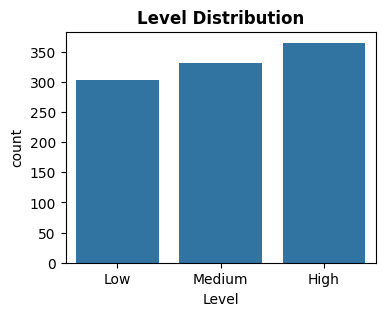

In [124]:
plt.figure(figsize=(4,3))

sns.countplot(
    data=df,
    x="Level"
)
plt.title("Level Distribution", fontsize=12, fontweight="bold")

# 3. EDA

## 3.1 Histograms / Bar Graph
Analyze Shape (Bell? Skewed?), Modality, Center, Spread

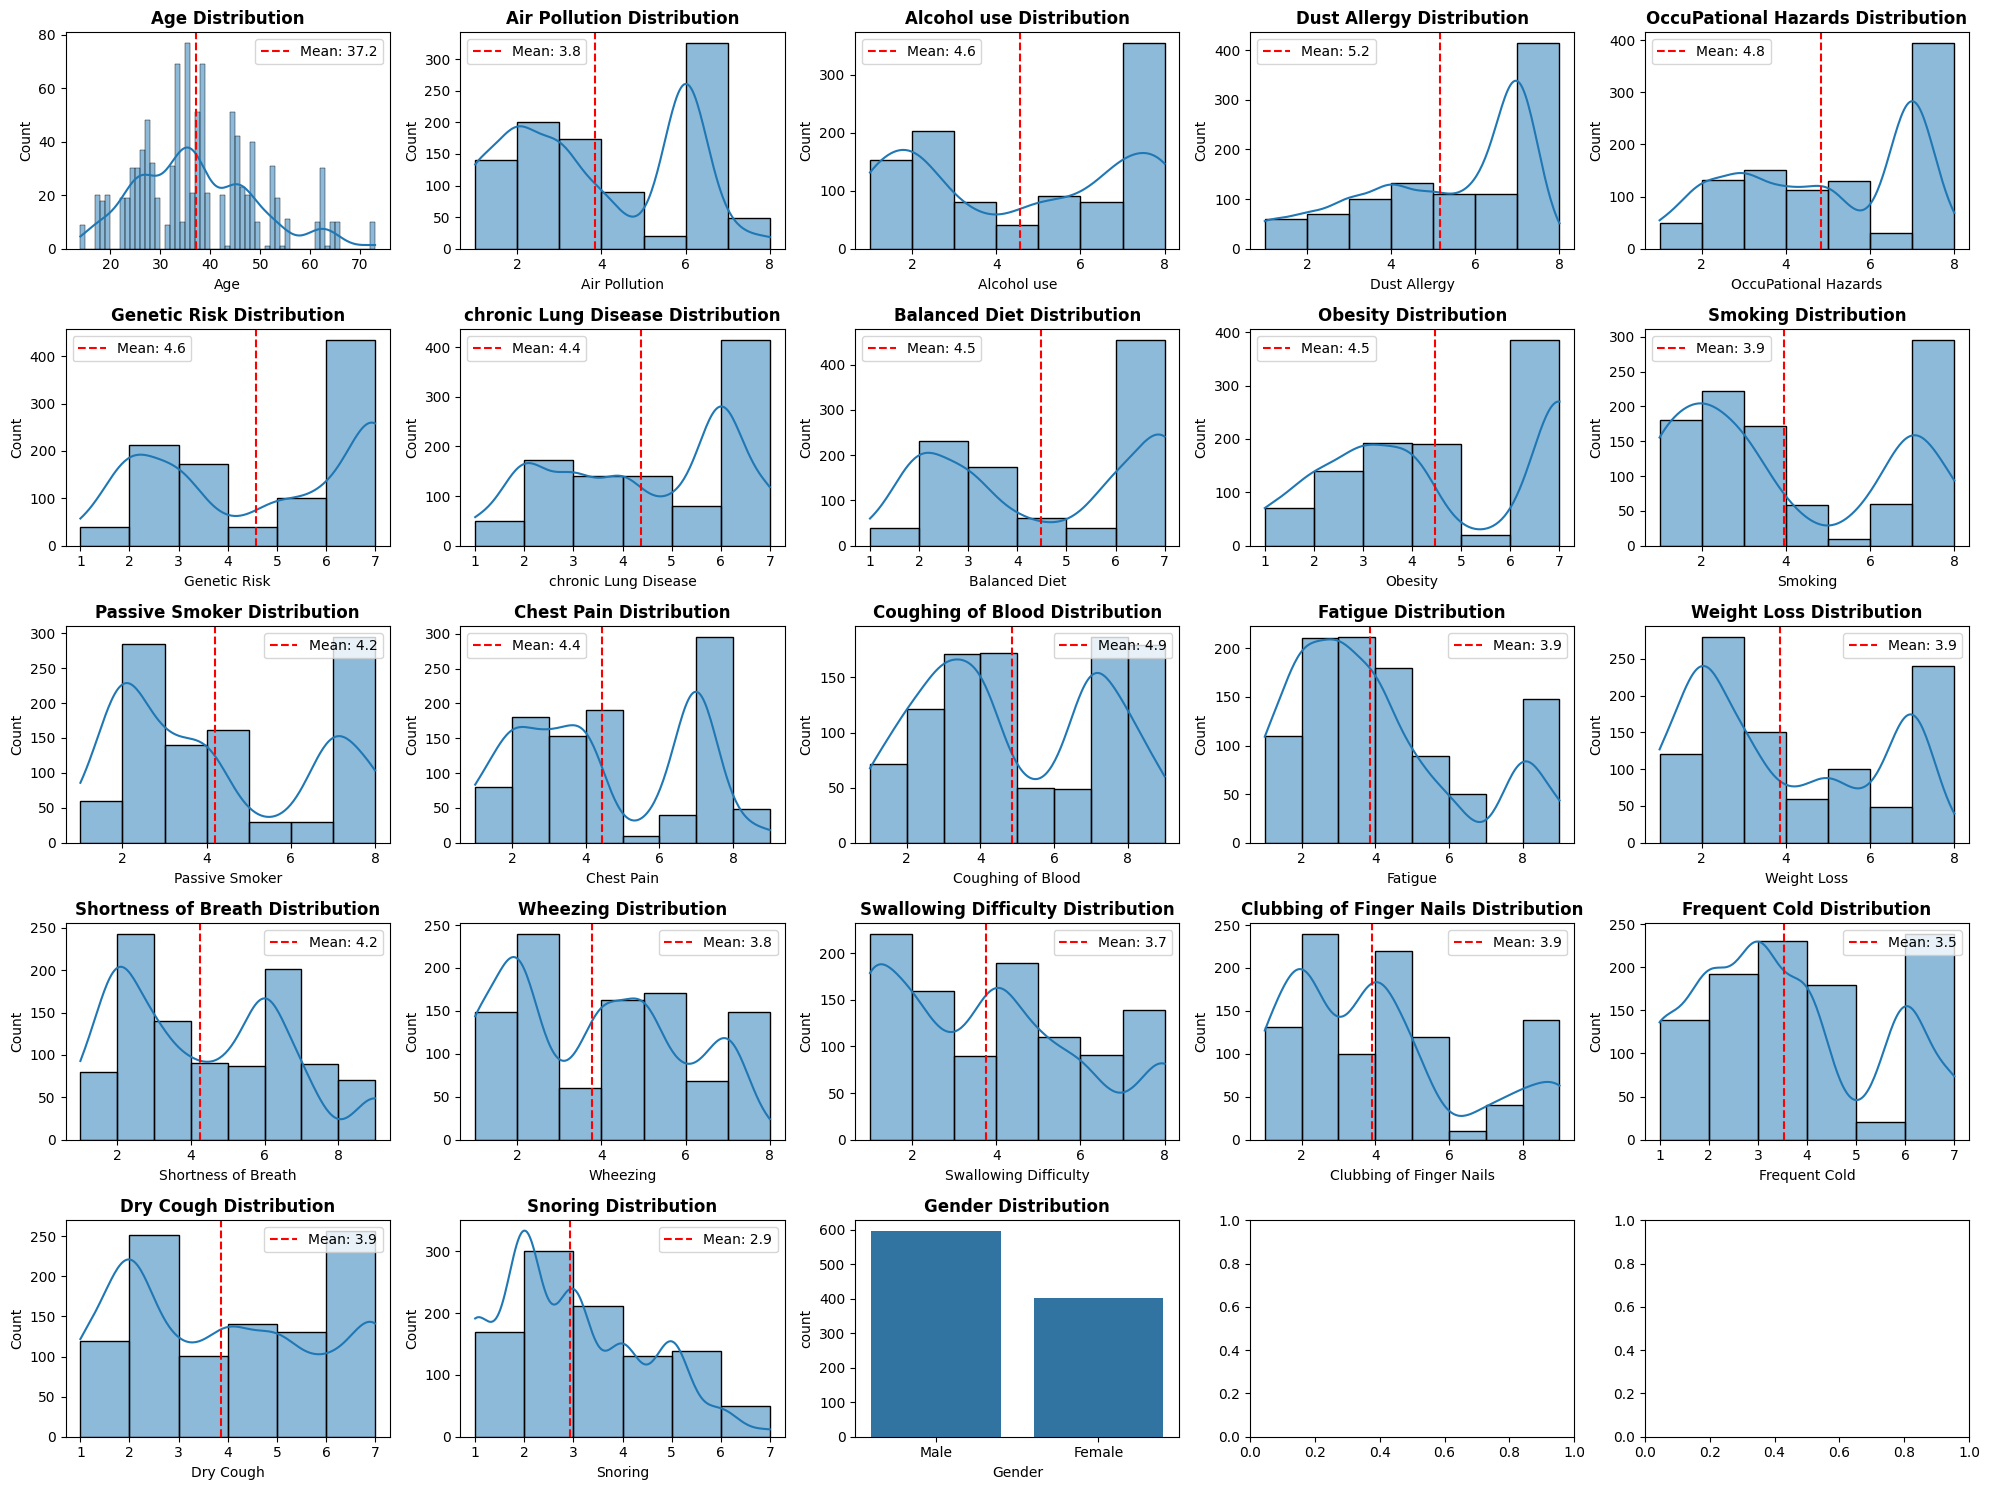

In [3]:
numeric_cols = df.select_dtypes(include="number").columns
numeric_cols = [col for col in numeric_cols if col != "Gender"]#[:10]

fig, axes = plt.subplots(5, 5, figsize=(20,15))
axes = axes.flatten()

for i, feature in enumerate(numeric_cols):
    sns.histplot(
        data=df,
        x=feature,
        bins=df[feature].max() - df[feature].min(),
        kde=True,
        ax=axes[i]
    )

    axes[i].set_title(f"{feature} Distribution", fontsize=12, fontweight="bold")

    axes[i].axvline(
        df[feature].mean(),
        color='red',
        linestyle='--',
        label=f"Mean: {df[feature].mean():.1f}"
    )

    axes[i].legend()

sns.countplot(
    data=df,
    x="Gender",
    ax=axes[22]
)
axes[22].set_title("Gender Distribution", fontsize=12, fontweight="bold")
axes[22].set_xticks([0,1], ["Male", "Female"])

plt.tight_layout() # to prevent leaking of titles/axis labels
plt.show()

## 3.2 Box Plots
Analyze Outliers, Compare Distributions

Single Outlier in Age

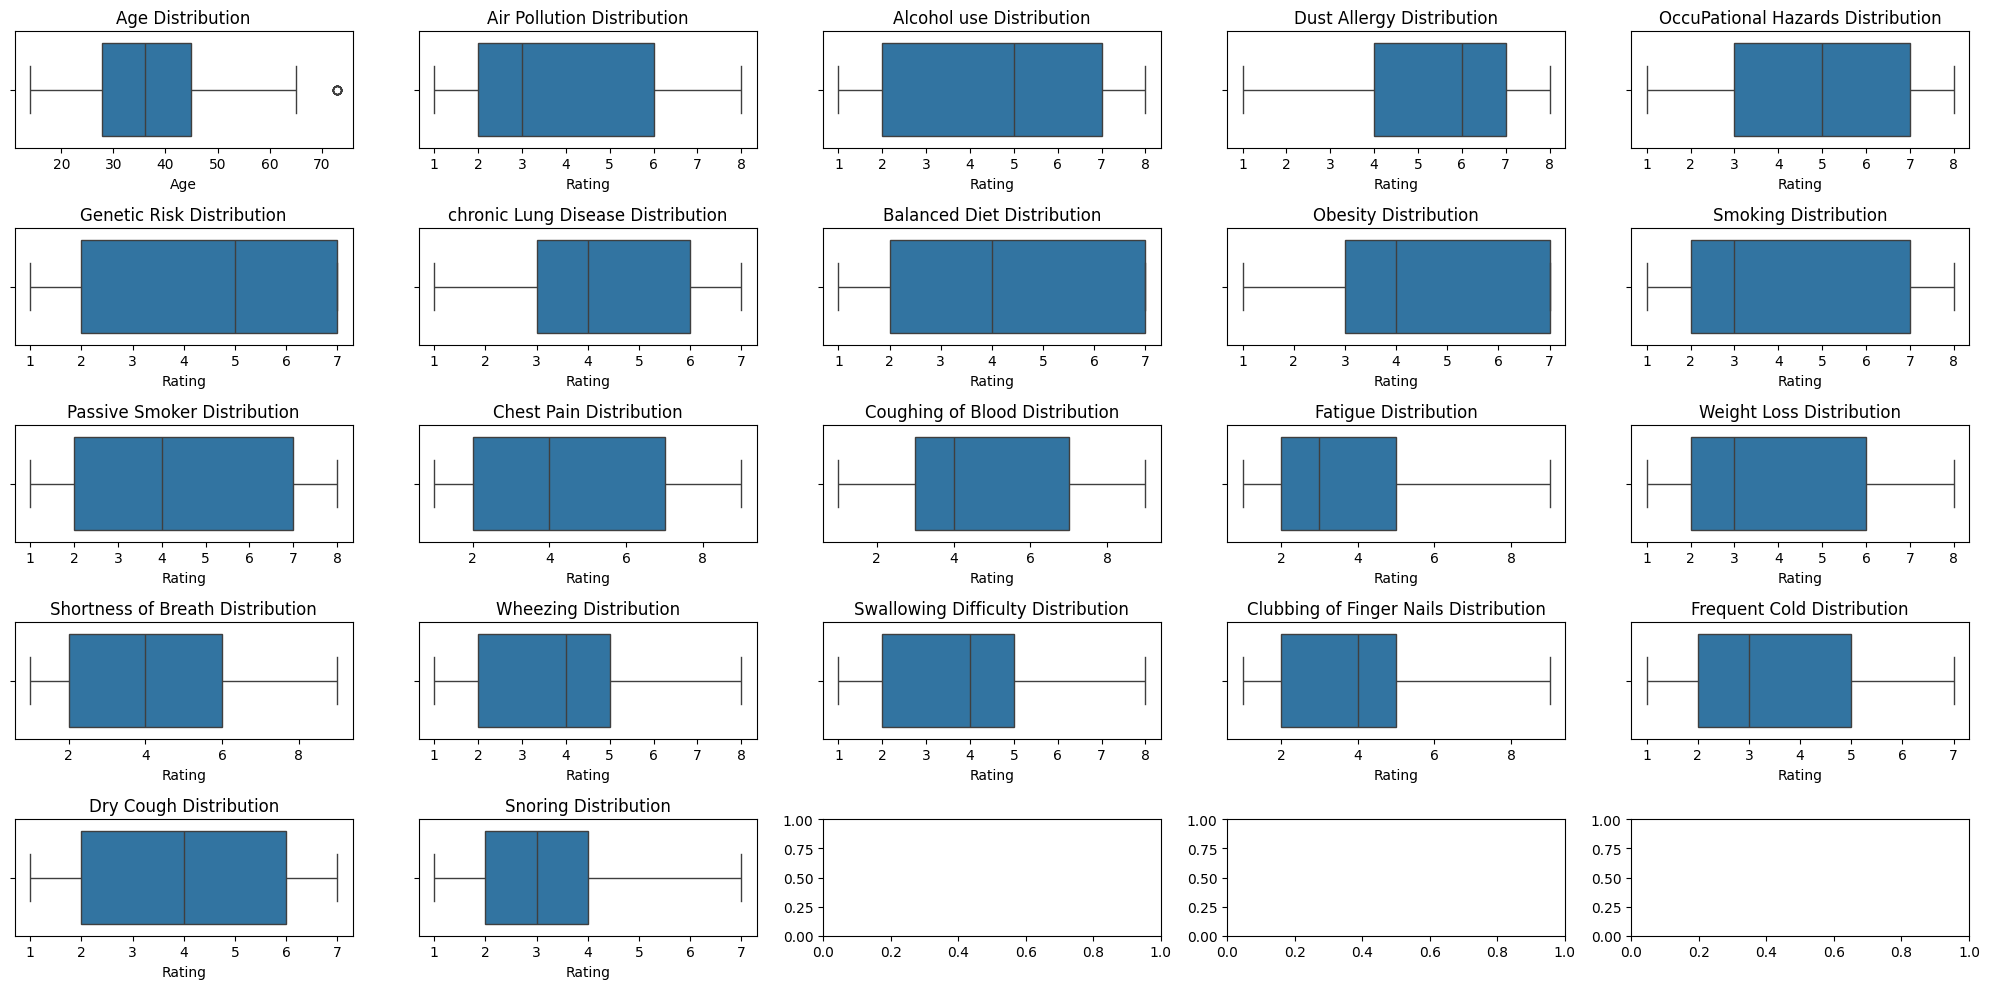

In [122]:
fig, axes = plt.subplots(5,5, figsize=(20,10))
axes = axes.flatten()

for i, feature in enumerate(numeric_cols):
    sns.boxplot(
        data=df,
        x=feature,
        ax=axes[i]
    )

    axes[i].set_title(f"{feature} Distribution")

    label = "Rating"
    if feature=="Age":
        label="Age"
    axes[i].set_xlabel(f"{label}")

plt.tight_layout()
plt.show()

# 4. Feature Selection

## 4.1 Visually - Box Plot (Feature Target)
The less overlap for each feature category the more related the feature to target
Alternative to Scatter Plot (require both feature and target to be continuous)

High Relation: Alcohol Use, Dust Allergy, Occupational Hazards, Obesity, Smoking. Fatigue

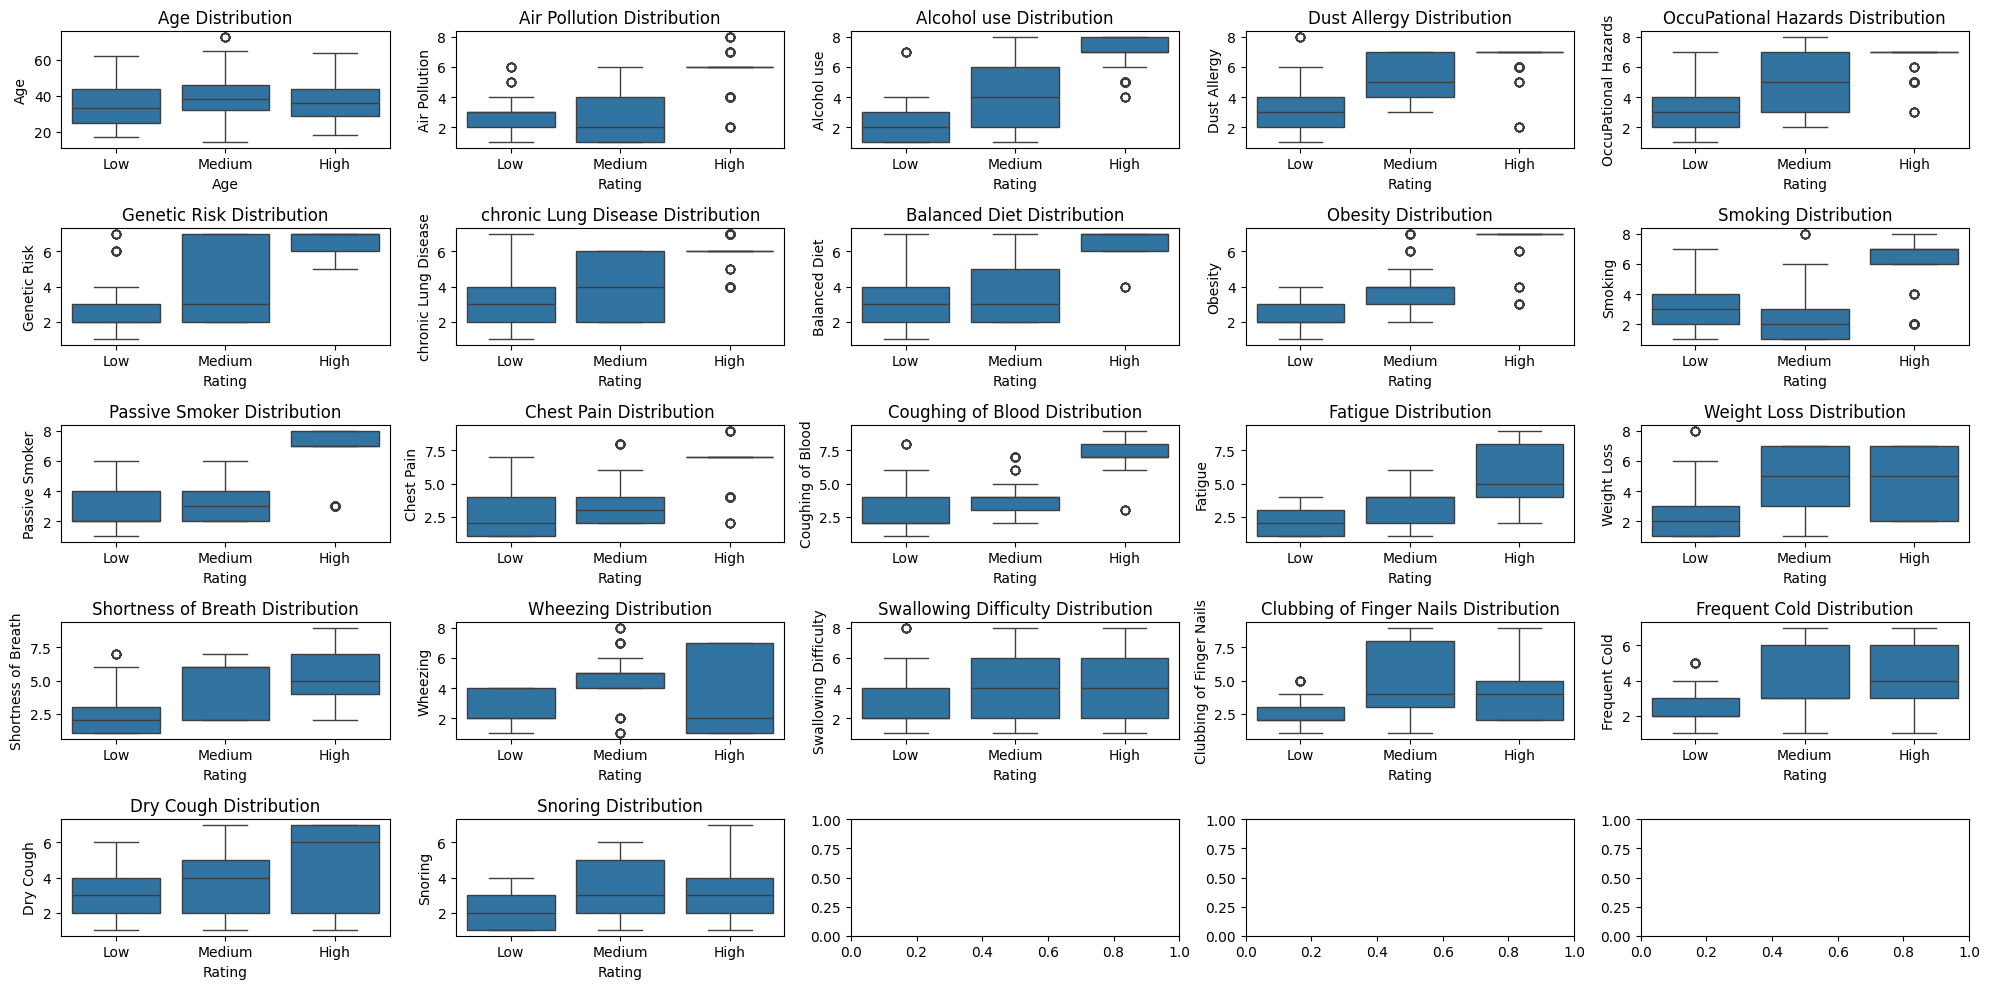

In [87]:
fig, axes = plt.subplots(5,5, figsize=(20,10))
axes = axes.flatten()

for i, feature in enumerate(numeric_cols):
    sns.boxplot(
        data=df,
        x="Level",
        y=feature,
        ax=axes[i]
    )

    axes[i].set_title(f"{feature} Distribution")

    label = "Rating"
    if feature=="Age":
        label="Age"
    axes[i].set_xlabel(f"{label}")

plt.tight_layout()
plt.show()

## 4.2 Pearson Corelation Coefficient

In [105]:
# Mapping Label Classes to Numeric Values as PCC works on Continuous variables 
df_encoded = df.copy()
df_encoded["Level"].replace({"Low":0, "Medium":1, "High":2}, inplace=True)

/tmp/ipykernel_119797/688749436.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_encoded["Level"].replace({"Low":0, "Medium":1, "High":2}, inplace=True)
/tmp/ipykernel_119797/688749436.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_encoded["Level"].replace({"Low":0, "Medium":1, "High":

Selecting Features (threshold 50%)

In [123]:
correlation_with_target = df_encoded[numeric_cols + ['Level']].corr(method='pearson')['Level'].round(4) * 100
print(correlation_with_target[ correlation_with_target>50 ])

Air Pollution            63.60
Alcohol use              71.87
Dust Allergy             71.38
OccuPational Hazards     67.33
Genetic Risk             70.13
chronic Lung Disease     61.00
Balanced Diet            70.63
Obesity                  82.74
Smoking                  51.95
Passive Smoker           70.36
Chest Pain               64.55
Coughing of Blood        78.21
Fatigue                  62.51
Level                   100.00
Name: Level, dtype: float64


# 5. Feature Scaling
Required since KNN relies on distance for similarity <br>
Features with larger ranges will dominate otherwise <br>
Applied Standard Scaling (Mean=0 , Std=1)

In [7]:
scaler = StandardScaler()
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])